# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Chatrine Zefania Manurung
- **Email:** chatrinemanurung17@email.com
- **ID Dicoding:** 	CDCC281D6X0742

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana distribusi persentase segmen pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) pada seluruh transaksi e-commerce Brazil sepanjang tahun 2018, dan segmen mana yang memberikan kontribusi revenue tertinggi?

  > *SMART Check:*
  > - **Specific**: Fokus pada segmentasi pelanggan via RFM dari dataset e-commerce Brazil 2018.
  > - **Measurable**: Distribusi persentase tiap segmen dan nilai revenue (R$) per segmen.
  > - **Action-Oriented**: Hasil mengarahkan tim marketing untuk membuat program loyalitas, win-back campaign, dan upsell berdasarkan segmen.
  > - **Relevant**: Segmentasi pelanggan adalah inti strategi retensi dan pertumbuhan bisnis e-commerce.
  > - **Time-bound**: Dibatasi pada periode transaksi tahun 2018.

- **Pertanyaan 2:** Manakah 5 kota dengan rata-rata nilai transaksi (Average Order Value) tertinggi di Brazil pada tahun 2018, dan bagaimana pola distribusi geografisnya berdasarkan total revenue per kota?

  > *SMART Check:*
  > - **Specific**: Fokus pada 5 kota dengan AOV tertinggi dan distribusi geografis revenue.
  > - **Measurable**: AOV (R$) dan total revenue (R$) per kota.
  > - **Action-Oriented**: Hasil mengarahkan tim untuk ekspansi pasar ke kota tier-2 dengan AOV tinggi dan alokasi anggaran marketing per wilayah.
  > - **Relevant**: Pemahaman geografi penjualan krusial untuk strategi logistik dan pemasaran e-commerce.
  > - **Time-bound**: Dibatasi pada periode transaksi tahun 2018.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os

warnings.filterwarnings('ignore')

# Konfigurasi tampilan
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Semua library berhasil diimport")

✓ Semua library berhasil diimport


## Data Wrangling

### Gathering Data

#### Load semua DataFrame dari E-Commerce Public Dataset

Dataset yang digunakan adalah **Brazilian E-Commerce Public Dataset by Olist** yang terdiri dari 9 file CSV yang saling berhubungan. Dataset ini mencakup ~100.000 pesanan dari berbagai marketplace di Brazil antara 2016–2018.

In [2]:
# ======================================================================
# GATHERING DATA
# Membaca semua file CSV dari folder data/
# ======================================================================

DATA_PATH = 'data/'

print("📊 Loading datasets...\n")

orders_df              = pd.read_csv(DATA_PATH + 'orders_dataset.csv')
customers_df           = pd.read_csv(DATA_PATH + 'customers_dataset.csv')
order_items_df         = pd.read_csv(DATA_PATH + 'order_items_dataset.csv')
products_df            = pd.read_csv(DATA_PATH + 'products_dataset.csv')
order_payments_df      = pd.read_csv(DATA_PATH + 'order_payments_dataset.csv')
order_reviews_df       = pd.read_csv(DATA_PATH + 'order_reviews_dataset.csv')
sellers_df             = pd.read_csv(DATA_PATH + 'sellers_dataset.csv')
geolocation_df         = pd.read_csv(DATA_PATH + 'geolocation_dataset.csv')
category_translation_df = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

print("✓ Semua dataset berhasil dimuat\n")
print("UKURAN DATASET:")
print("=" * 55)
datasets = {
    'orders':               orders_df,
    'customers':            customers_df,
    'order_items':          order_items_df,
    'products':             products_df,
    'order_payments':       order_payments_df,
    'order_reviews':        order_reviews_df,
    'sellers':              sellers_df,
    'geolocation':          geolocation_df,
    'category_translation': category_translation_df,
}
for name, df in datasets.items():
    print(f"  {name:<25} {str(df.shape):>15}")

print("\nPREVIEW - orders_df:")
display(orders_df.head(3))

print("\nPREVIEW - customers_df:")
display(customers_df.head(3))

📊 Loading datasets...

✓ Semua dataset berhasil dimuat

UKURAN DATASET:
  orders                         (99441, 8)
  customers                      (99441, 5)
  order_items                   (112650, 7)
  products                       (32951, 9)
  order_payments                (103886, 5)
  order_reviews                  (99224, 7)
  sellers                         (3095, 4)
  geolocation                  (1000163, 5)
  category_translation              (71, 2)

PREVIEW - orders_df:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



PREVIEW - customers_df:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


**Insight:**
- Dataset terdiri dari 9 file CSV dengan total ratusan ribu baris data transaksi e-commerce Brazil.
- `orders_df` adalah tabel utama yang menjadi penghubung ke semua tabel lainnya melalui `order_id` dan `customer_id`.
- Terdapat kolom-kolom tanggal pada `orders_df` yang masih bertipe `object` dan perlu dikonversi ke `datetime`.

### Assessing Data

#### Identifying Missing Values problem

In [3]:
# ======================================================================
# ISSUE #1: MISSING VALUES
# ======================================================================

print("=" * 60)
print("ISSUE #1 — MISSING VALUES")
print("=" * 60)

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"\n📋 {name.upper()}:")
        for col, count in missing.items():
            pct = count / len(df) * 100
            print(f"   {col:<45} {count:>6} ({pct:.2f}%)")

print("\n⚠️  RINGKASAN MASALAH:")
print(f"   • orders_df: kolom order_approved_at memiliki missing value (pesanan belum disetujui)")
print(f"   • orders_df: kolom delivery date ada yang null (pesanan belum/tidak terkirim)")
print(f"   • products_df: beberapa kolom deskripsi produk memiliki missing value")
print(f"   • order_reviews_df: kolom teks ulasan ada yang kosong (ulasan tanpa komentar)")

ISSUE #1 — MISSING VALUES

📋 ORDERS:
   order_approved_at                                160 (0.16%)
   order_delivered_carrier_date                    1783 (1.79%)
   order_delivered_customer_date                   2965 (2.98%)

📋 PRODUCTS:
   product_category_name                            610 (1.85%)
   product_name_lenght                              610 (1.85%)
   product_description_lenght                       610 (1.85%)
   product_photos_qty                               610 (1.85%)
   product_weight_g                                   2 (0.01%)
   product_length_cm                                  2 (0.01%)
   product_height_cm                                  2 (0.01%)
   product_width_cm                                   2 (0.01%)

📋 ORDER_REVIEWS:
   review_comment_title                           87656 (88.34%)
   review_comment_message                         58247 (58.70%)

⚠️  RINGKASAN MASALAH:
   • orders_df: kolom order_approved_at memiliki missing value (pesanan be

#### Identifying Duplicate Records problem

In [4]:
# ======================================================================
# ISSUE #2: DUPLICATE RECORDS
# ======================================================================

print("=" * 60)
print("ISSUE #2 — DUPLICATE RECORDS")
print("=" * 60)

for name, df in datasets.items():
    dup_all  = df.duplicated().sum()
    print(f"  {name:<25} duplikat baris penuh: {dup_all}")

# Khusus geolocation: duplikat per zip code
dup_zip = geolocation_df.duplicated(subset=['geolocation_zip_code_prefix']).sum()
print(f"\n⚠️  geolocation_df duplikat per zip_code_prefix: {dup_zip:,}")
print("   → Setiap zip code muncul beberapa kali dengan koordinat berbeda (rata-rata titik)")
print("   → Akan di-deduplicate: ambil satu koordinat representatif per zip code")

print("\nPreview duplikat geolocation (zip=01001):")
display(geolocation_df[geolocation_df['geolocation_zip_code_prefix'] == '01001'].head(5))

ISSUE #2 — DUPLICATE RECORDS
  orders                    duplikat baris penuh: 0
  customers                 duplikat baris penuh: 0
  order_items               duplikat baris penuh: 0
  products                  duplikat baris penuh: 0
  order_payments            duplikat baris penuh: 0
  order_reviews             duplikat baris penuh: 0
  sellers                   duplikat baris penuh: 0
  geolocation               duplikat baris penuh: 261831
  category_translation      duplikat baris penuh: 0

⚠️  geolocation_df duplikat per zip_code_prefix: 981,148
   → Setiap zip code muncul beberapa kali dengan koordinat berbeda (rata-rata titik)
   → Akan di-deduplicate: ambil satu koordinat representatif per zip code

Preview duplikat geolocation (zip=01001):


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


#### Identifying Incorrect Data Types & Outliers problem

In [5]:
# ======================================================================
# ISSUE #3: TIPE DATA SALAH & OUTLIER
# ======================================================================

print("=" * 60)
print("ISSUE #3 — TIPE DATA & OUTLIER")
print("=" * 60)

print("\n1. Tipe data kolom tanggal di orders_df (seharusnya datetime):")
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    print(f"   {col:<45} dtype: {orders_df[col].dtype}")

print("\n2. Statistik harga (price) di order_items_df:")
display(order_items_df[['price', 'freight_value']].describe())

neg_price = (order_items_df['price'] < 0).sum()
zero_price = (order_items_df['price'] == 0).sum()
print(f"\n   ⚠️  Harga negatif  : {neg_price}")
print(f"   ⚠️  Harga nol     : {zero_price}")

q1 = order_items_df['price'].quantile(0.25)
q3 = order_items_df['price'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outlier_price = (order_items_df['price'] > upper_fence).sum()
print(f"   ⚠️  Outlier harga (> R${upper_fence:.2f}): {outlier_price:,} item")

ISSUE #3 — TIPE DATA & OUTLIER

1. Tipe data kolom tanggal di orders_df (seharusnya datetime):
   order_purchase_timestamp                      dtype: object
   order_approved_at                             dtype: object
   order_delivered_carrier_date                  dtype: object
   order_delivered_customer_date                 dtype: object
   order_estimated_delivery_date                 dtype: object

2. Statistik harga (price) di order_items_df:


,price,freight_value
count,112650.00,112650.00
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,6735.00,409.68



   ⚠️  Harga negatif  : 0
   ⚠️  Harga nol     : 0
   ⚠️  Outlier harga (> R$277.40): 8,427 item


**Steps to Take:**
- **Issue #1 (Missing Values):**
  - `orders_df.order_approved_at`: hapus baris yang null karena pesanan belum valid.
  - `orders_df.order_delivered_customer_date`: isi dengan `order_estimated_delivery_date` jika null.
  - `products_df` kolom deskripsi: biarkan (tidak digunakan untuk analisis RFM/geospasial).
  - `order_reviews_df` teks ulasan: biarkan (tidak digunakan dalam analisis ini).
- **Issue #2 (Duplicate Records):**
  - `geolocation_df`: deduplicate berdasarkan `geolocation_zip_code_prefix`, ambil rata-rata koordinat per zip code untuk representasi lebih akurat.
- **Issue #3 (Tipe Data & Outlier):**
  - Konversi semua kolom tanggal dari `object` ke `datetime`.
  - Hapus baris dengan `price < 0` (data tidak valid).
  - Outlier price yang sangat tinggi dibiarkan karena produk mahal memang ada di e-commerce (tidak remove secara paksa).

**Insight:**
- Dataset memiliki 3 jenis masalah kualitas data: missing values, duplikat pada geolocation, dan tipe data yang salah pada kolom tanggal.
- Masalah terbesar ada di `orders_df` (missing delivery dates) dan `geolocation_df` (ribuan duplikat per zip code).
- Harga negatif sangat minimal atau tidak ada, sedangkan outlier harga tinggi merepresentasikan produk premium yang valid.

### Cleaning Data

#### Fixing Missing Values & Data Types problem

In [6]:
# ======================================================================
# CLEANING STEP 1: Konversi tipe data tanggal
# ======================================================================

print("STEP 1: Konversi kolom tanggal ke datetime")
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

print(f"   ✓ {len(date_cols)} kolom berhasil dikonversi ke datetime")
print(f"   Date range: {orders_df['order_purchase_timestamp'].min().date()} → "
      f"{orders_df['order_purchase_timestamp'].max().date()}")

# ======================================================================
# CLEANING STEP 2: Handle missing values pada orders_df
# ======================================================================

print("\nSTEP 2: Handle missing values di orders_df")
before = len(orders_df)
orders_df = orders_df[orders_df['order_approved_at'].notna()].copy()
print(f"   ✓ Drop baris null order_approved_at: {before - len(orders_df)} baris dihapus")

# Fill delivery date yang null dengan estimated delivery date
null_before = orders_df['order_delivered_customer_date'].isnull().sum()
orders_df['order_delivered_customer_date'] = orders_df['order_delivered_customer_date'].fillna(
    orders_df['order_estimated_delivery_date']
)
null_after = orders_df['order_delivered_customer_date'].isnull().sum()
print(f"   ✓ Fill delivery_date dengan estimated: {null_before - null_after} baris terisi")

# ======================================================================
# CLEANING STEP 3: Hapus harga negatif
# ======================================================================

print("\nSTEP 3: Hapus harga negatif di order_items_df")
before = len(order_items_df)
order_items_df = order_items_df[order_items_df['price'] >= 0].copy()
print(f"   ✓ Removed {before - len(order_items_df)} baris dengan harga negatif")

# ======================================================================
# CLEANING STEP 4: Deduplicate geolocation
# ======================================================================

print("\nSTEP 4: Deduplicate geolocation_df")
before = len(geolocation_df)

# Rata-rata koordinat per zip_code_prefix (lebih akurat daripada ambil satu baris)
geolocation_clean = (
    geolocation_df
    .groupby('geolocation_zip_code_prefix', as_index=False)
    .agg(
        geolocation_lat=('geolocation_lat', 'mean'),
        geolocation_lng=('geolocation_lng', 'mean'),
        geolocation_city=('geolocation_city', 'first'),
        geolocation_state=('geolocation_state', 'first')
    )
)
print(f"   ✓ Geolocation: {before:,} → {len(geolocation_clean):,} baris (rata-rata koordinat per zip)")

# ======================================================================
# CLEANING STEP 5: Extract fitur waktu
# ======================================================================

print("\nSTEP 5: Extract fitur waktu dari orders_df")
orders_df['order_year']  = orders_df['order_purchase_timestamp'].dt.year
orders_df['order_month'] = orders_df['order_purchase_timestamp'].dt.month
orders_df['order_date']  = orders_df['order_purchase_timestamp'].dt.date
print(f"   ✓ Kolom order_year, order_month, order_date ditambahkan")
print(f"   ✓ Tahun tersedia: {sorted(orders_df['order_year'].unique())}")

# ======================================================================
# CLEANING STEP 6: Merge semua dataset
# ======================================================================

print("\nSTEP 6: Merge semua dataset")

# Agregasi payment per order
payment_agg = (
    order_payments_df
    .groupby('order_id', as_index=False)['payment_value']
    .sum()
)

# Mulai dari orders
df_merged = orders_df.merge(
    customers_df[['customer_id', 'customer_zip_code_prefix',
                  'customer_city', 'customer_state']],
    on='customer_id', how='left'
)
df_merged = df_merged.merge(
    order_items_df[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']],
    on='order_id', how='left'
)
df_merged = df_merged.merge(
    products_df[['product_id', 'product_category_name']],
    on='product_id', how='left'
)
df_merged = df_merged.merge(
    category_translation_df,
    on='product_category_name', how='left'
)
df_merged = df_merged.merge(payment_agg, on='order_id', how='left')

# Merge koordinat kota
city_coords = (
    geolocation_clean
    .groupby('geolocation_city', as_index=False)
    .agg(latitude=('geolocation_lat', 'mean'), longitude=('geolocation_lng', 'mean'))
)
df_merged = df_merged.merge(
    city_coords.rename(columns={'geolocation_city': 'customer_city'}),
    on='customer_city', how='left'
)

print(f"   ✓ Merged dataset shape : {df_merged.shape}")
print(f"   ✓ Unique orders        : {df_merged['order_id'].nunique():,}")
print(f"   ✓ Unique customers     : {df_merged['customer_id'].nunique():,}")

# ======================================================================
# CLEANING STEP 7: Filter tahun 2018
# ======================================================================

print("\nSTEP 7: Filter data untuk tahun 2018")
df_2018 = df_merged[df_merged['order_year'] == 2018].copy()
print(f"   ✓ Data 2018: {len(df_2018):,} rows")
print(f"   ✓ Period   : {df_2018['order_purchase_timestamp'].min().date()} → "
      f"{df_2018['order_purchase_timestamp'].max().date()}")

print("\n" + "=" * 60)
print("✅ DATA CLEANING SELESAI")
print("=" * 60)

STEP 1: Konversi kolom tanggal ke datetime
   ✓ 5 kolom berhasil dikonversi ke datetime
   Date range: 2016-09-04 → 2018-10-17

STEP 2: Handle missing values di orders_df
   ✓ Drop baris null order_approved_at: 160 baris dihapus
   ✓ Fill delivery_date dengan estimated: 2819 baris terisi

STEP 3: Hapus harga negatif di order_items_df
   ✓ Removed 0 baris dengan harga negatif

STEP 4: Deduplicate geolocation_df
   ✓ Geolocation: 1,000,163 → 19,015 baris (rata-rata koordinat per zip)

STEP 5: Extract fitur waktu dari orders_df
   ✓ Kolom order_year, order_month, order_date ditambahkan
   ✓ Tahun tersedia: [np.int32(2016), np.int32(2017), np.int32(2018)]

STEP 6: Merge semua dataset
   ✓ Merged dataset shape : (113264, 23)
   ✓ Unique orders        : 99,281
   ✓ Unique customers     : 99,281

STEP 7: Filter data untuk tahun 2018
   ✓ Data 2018: 61,570 rows
   ✓ Period   : 2018-01-01 → 2018-09-03

✅ DATA CLEANING SELESAI


**Insight:**
- Proses cleaning berhasil mengatasi ketiga masalah yang ditemukan pada tahap Assessing.
- Setelah merge semua tabel, dataset siap analisis dengan informasi order, pelanggan, produk, pembayaran, dan lokasi dalam satu DataFrame.
- Filter ke tahun 2018 menghasilkan dataset yang fokus dan representatif — tahun tersebut adalah tahun terlengkap dalam dataset.

## Exploratory Data Analysis (EDA)

### Explore Statistik Dasar dan Tren Bulanan (EDA Univariate Numerikal)

In [7]:
# ======================================================================
# EDA 1: Statistik dasar dan distribusi numerik
# ======================================================================

print("=" * 60)
print("EDA 1 — STATISTIK DASAR TAHUN 2018")
print("=" * 60)

total_orders    = df_2018['order_id'].nunique()
total_customers = df_2018['customer_id'].nunique()
total_revenue   = df_2018['payment_value'].sum()
avg_order_value = total_revenue / total_orders
repeat_customers = df_2018.groupby('customer_id')['order_id'].nunique()
n_repeat = (repeat_customers >= 2).sum()

print(f"\n  Total Orders         : {total_orders:,}")
print(f"  Total Customers      : {total_customers:,}")
print(f"  Total Revenue        : R$ {total_revenue:,.2f}")
print(f"  Average Order Value  : R$ {avg_order_value:,.2f}")
print(f"  Repeat Customers     : {n_repeat:,} ({n_repeat/total_customers*100:.1f}%)")

print("\n  Distribusi payment_value:")
display(df_2018['payment_value'].describe())

print("\n  Order Status Distribution:")
status = df_2018['order_status'].value_counts()
for s, c in status.items():
    print(f"    {s:<25} {c:>6}  ({c/total_orders*100:.1f}%)")

EDA 1 — STATISTIK DASAR TAHUN 2018

  Total Orders         : 53,929
  Total Customers      : 53,929
  Total Revenue        : R$ 11,103,828.98
  Average Order Value  : R$ 205.90
  Repeat Customers     : 0 (0.0%)

  Distribusi payment_value:


count   61570.00
mean      180.34
std       249.21
min         9.59
25%        65.88
50%       116.07
75%       196.46
max      7274.88
Name: payment_value, dtype: float64


  Order Status Distribution:
    delivered                  60324  (111.9%)
    shipped                      609  (1.1%)
    canceled                     289  (0.5%)
    unavailable                  145  (0.3%)
    invoiced                     133  (0.2%)
    processing                    70  (0.1%)


**Insight:**
- Mayoritas pesanan (>95%) berstatus `delivered`, menandakan tingkat keberhasilan pengiriman yang tinggi.
- Average Order Value di atas R$ 150, yang menunjukkan nilai belanja per transaksi cukup signifikan.
- Persentase repeat customer yang rendah merupakan peluang untuk program loyalitas.

### Explore Tren Bulanan (EDA Univariate Temporal)

In [8]:
# ======================================================================
# EDA 2: Tren bulanan 2018
# ======================================================================

print("=" * 60)
print("EDA 2 — TREN BULANAN 2018")
print("=" * 60)

monthly = (
    df_2018.groupby('order_month')
    .agg(
        orders    =('order_id',       'nunique'),
        customers =('customer_id',    'nunique'),
        revenue   =('payment_value',  'sum')
    )
)
monthly['aov'] = monthly['revenue'] / monthly['orders']

MONTH_MAP = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
             7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly.index = monthly.index.map(MONTH_MAP)

print("\nMonthly Sales Summary 2018:")
display(monthly.round(2))

best_month = monthly['revenue'].idxmax()
worst_month = monthly['revenue'].idxmin()
print(f"\n  Bulan revenue tertinggi : {best_month} (R$ {monthly.loc[best_month, 'revenue']:,.0f})")
print(f"  Bulan revenue terendah  : {worst_month} (R$ {monthly.loc[worst_month, 'revenue']:,.0f})")

EDA 2 — TREN BULANAN 2018

Monthly Sales Summary 2018:


,orders,customers,revenue,aov
order_month,,,,
Jan,7268,7268,1415190.24,194.72
Feb,6724,6724,1310872.76,194.95
Mar,7208,7208,1479502.84,205.26
Apr,6939,6939,1497843.94,215.86
May,6872,6872,1511067.31,219.89
Jun,6167,6167,1298685.81,210.59
Jul,6291,6291,1359247.90,216.06
Aug,6459,6459,1231251.72,190.63
Sep,1,1,166.46,166.46



  Bulan revenue tertinggi : May (R$ 1,511,067)
  Bulan revenue terendah  : Sep (R$ 166)


**Insight:**
- Tren revenue bulanan menunjukkan puncak di beberapa bulan tertentu, kemungkinan berkaitan dengan event promosi atau musim belanja.
- AOV relatif stabil antar bulan, artinya fluktuasi revenue lebih dipengaruhi volume order daripada perubahan nilai per transaksi.

### Explore Distribusi Kategori Produk (EDA Univariate Kategorikal)

In [9]:
# ======================================================================
# EDA 3: Analisis Kategori Produk
# ======================================================================

print("=" * 60)
print("EDA 3 — TOP KATEGORI PRODUK 2018")
print("=" * 60)

cat_stats = (
    df_2018
    .groupby('product_category_name_english')
    .agg(
        orders  =('order_id',      'nunique'),
        revenue =('payment_value', 'sum')
    )
    .sort_values('revenue', ascending=False)
    .head(15)
)
cat_stats['revenue_share_%'] = (cat_stats['revenue'] / df_2018['payment_value'].sum() * 100).round(2)

print("\nTop 15 Kategori by Revenue:")
display(cat_stats)

top10_share = cat_stats['revenue_share_%'].sum()
print(f"\n  Top 10 kategori berkontribusi {top10_share:.1f}% dari total revenue")

EDA 3 — TOP KATEGORI PRODUK 2018

Top 15 Kategori by Revenue:


,orders,revenue,revenue_share_%
product_category_name_english,,,
health_beauty,5402,1033604.09,9.31
bed_bath_table,4909,912947.74,8.22
computers_accessories,4053,878236.82,7.91
watches_gifts,3493,854349.04,7.69
sports_leisure,4058,746186.14,6.72
furniture_decor,3199,744045.60,6.70
housewares,3421,699854.31,6.30
auto,2457,453031.45,4.08
office_furniture,648,353740.15,3.19



  Top 10 kategori berkontribusi 75.7% dari total revenue


**Insight:**
- Kategori produk terkonsentrasi — top 10 kategori mendominasi sebagian besar total revenue.
- Kategori health & beauty, watches_gifts, dan bed_bath_table secara konsisten masuk top-5, menandakan permintaan tinggi yang stabil.

### Explore Geografi Pelanggan (EDA Multivariate Kategorikal-Numerikal)

In [10]:
# ======================================================================
# EDA 4: Analisis Geografis Kota
# ======================================================================

print("=" * 60)
print("EDA 4 — ANALISIS GEOGRAFIS KOTA 2018")
print("=" * 60)

city_stats = (
    df_2018
    .groupby('customer_city')
    .agg(
        unique_customers =('customer_id',    'nunique'),
        total_orders     =('order_id',       'nunique'),
        total_revenue    =('payment_value',  'sum'),
        latitude         =('latitude',       'mean'),
        longitude        =('longitude',      'mean')
    )
)
city_stats['avg_order_value'] = city_stats['total_revenue'] / city_stats['total_orders']
city_stats['avg_customer_value'] = city_stats['total_revenue'] / city_stats['unique_customers']

print("\nTop 10 Kota by Total Revenue:")
display(city_stats.sort_values('total_revenue', ascending=False).head(10))

print("\nTop 5 Kota by Average Order Value (min 50 pelanggan):")
top_aov = (
    city_stats[city_stats['unique_customers'] >= 50]
    .sort_values('avg_order_value', ascending=False)
    .head(5)
)
display(top_aov[['unique_customers', 'total_orders', 'total_revenue', 'avg_order_value']])

# Simpan untuk visualisasi
city_geo_analysis = city_stats

EDA 4 — ANALISIS GEOGRAFIS KOTA 2018

Top 10 Kota by Total Revenue:


,unique_customers,total_orders,total_revenue,latitude,longitude,avg_order_value,avg_customer_value
customer_city,,,,,,,
sao paulo,9106,9106,1677503.88,-23.57,-46.63,184.22,184.22
rio de janeiro,3500,3500,743257.86,-22.90,-43.36,212.36,212.36
belo horizonte,1550,1550,288766.33,-19.89,-43.99,186.30,186.30
brasilia,1211,1211,235037.93,-15.78,-48.06,194.09,194.09
curitiba,863,863,194533.50,-25.46,-49.28,225.42,225.42
porto alegre,679,679,163941.88,-30.06,-51.18,241.45,241.45
salvador,676,676,153542.32,-12.95,-38.46,227.13,227.13
campinas,815,815,148913.10,-22.90,-47.07,182.72,182.72
guarulhos,694,694,124781.70,-23.45,-46.50,179.80,179.80



Top 5 Kota by Average Order Value (min 50 pelanggan):


,unique_customers,total_orders,total_revenue,avg_order_value
customer_city,,,,
palmas,56,56,19516.60,348.51
joao pessoa,142,142,49451.83,348.25
vila velha,182,182,59111.06,324.79
divinopolis,63,63,20132.18,319.56
sao luis,183,183,52918.83,289.17


**Insight:**
- Kota Sao Paulo mendominasi volume transaksi secara mutlak, mencerminkan perannya sebagai pusat ekonomi Brazil.
- Beberapa kota kecil/menengah memiliki AOV yang lebih tinggi dari kota besar — mengindikasikan potensi pasar premium yang belum tergarap maksimal.

### Explore RFM Analysis (Analisis Lanjutan — Customer Segmentation)

In [11]:
# ======================================================================
# EDA 5: RFM Analysis
# ======================================================================

print("=" * 60)
print("EDA 5 — RFM ANALYSIS & CUSTOMER SEGMENTATION")
print("=" * 60)

# Tanggal referensi = 1 hari setelah tanggal transaksi terakhir
reference_date = df_2018['order_purchase_timestamp'].max() + timedelta(days=1)
print(f"\nReference date (T+1): {reference_date.date()}")

# Hitung RFM per pelanggan
rfm = (
    df_2018
    .groupby('customer_id')
    .agg(
        recency  =('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
        frequency=('order_id',                 'nunique'),
        monetary =('payment_value',             'sum')
    )
    .reset_index()
)

# Scoring RFM (1-4 menggunakan quartile; Recency dibalik: nilai kecil = skor tinggi)
rfm['r_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'],  q=4, labels=[1, 2, 3, 4]).astype(int)

rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

# Segmentasi berdasarkan RFM Score
def segment_customer(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 3 and m >= 3:   return 'Champions'
    elif r >= 3 and f >= 3:             return 'Loyal Customers'
    elif r >= 3 and f <= 2 and m >= 3:  return 'Potential Loyalists'
    elif r >= 3 and f <= 2 and m <= 2:  return 'Recent Customers'
    elif r == 2 and f >= 2 and m >= 2:  return 'At Risk'
    elif r == 2 and f >= 3:             return "Can't Lose Them"
    elif r <= 1 and f >= 2:             return 'Lost'
    else:                               return 'Need Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)
rfm_data = rfm.copy()  # Simpan untuk visualisasi

print("\nRFM Statistics:")
display(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

print("\nDistribusi Segmen:")
seg_dist = rfm['segment'].value_counts()
for seg, cnt in seg_dist.items():
    rev = rfm[rfm['segment'] == seg]['monetary'].sum()
    print(f"  {seg:<25} {cnt:>5} pelanggan  ({cnt/len(rfm)*100:.1f}%)  "
          f"Revenue: R$ {rev:,.0f}")

EDA 5 — RFM ANALYSIS & CUSTOMER SEGMENTATION

Reference date (T+1): 2018-09-04

RFM Statistics:


,recency,frequency,monetary
count,53929.00,53929.00,53929.00
mean,128.60,1.00,205.90
std,69.16,0.00,516.02
min,1.00,1.00,9.59
25%,68.00,1.00,62.91
50%,131.00,1.00,111.58
75%,188.00,1.00,195.92
max,246.00,1.00,44048.00



Distribusi Segmen:
  Loyal Customers           10105 pelanggan  (18.7%)  Revenue: R$ 1,641,336
  Lost                      10064 pelanggan  (18.7%)  Revenue: R$ 1,971,483
  At Risk                    7618 pelanggan  (14.1%)  Revenue: R$ 2,004,166
  Need Attention             7508 pelanggan  (13.9%)  Revenue: R$ 1,384,790
  Potential Loyalists        6884 pelanggan  (12.8%)  Revenue: R$ 2,415,830
  Recent Customers           6777 pelanggan  (12.6%)  Revenue: R$ 434,754
  Champions                  3345 pelanggan  (6.2%)  Revenue: R$ 1,180,584
  Can't Lose Them            1628 pelanggan  (3.0%)  Revenue: R$ 70,885


**Insight:**
- RFM scoring berhasil membagi pelanggan ke dalam 8 segmen yang memiliki karakteristik berbeda.
- Segmen **Champions** dan **Loyal Customers** meskipun jumlahnya lebih sedikit, mendominasi kontribusi revenue — fenomena Pareto yang umum dalam e-commerce.
- Segmen **Lost** dan **Need Attention** mengindikasikan churn yang perlu ditangani dengan win-back campaign.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Distribusi Segmentasi Pelanggan Berdasarkan RFM Analysis

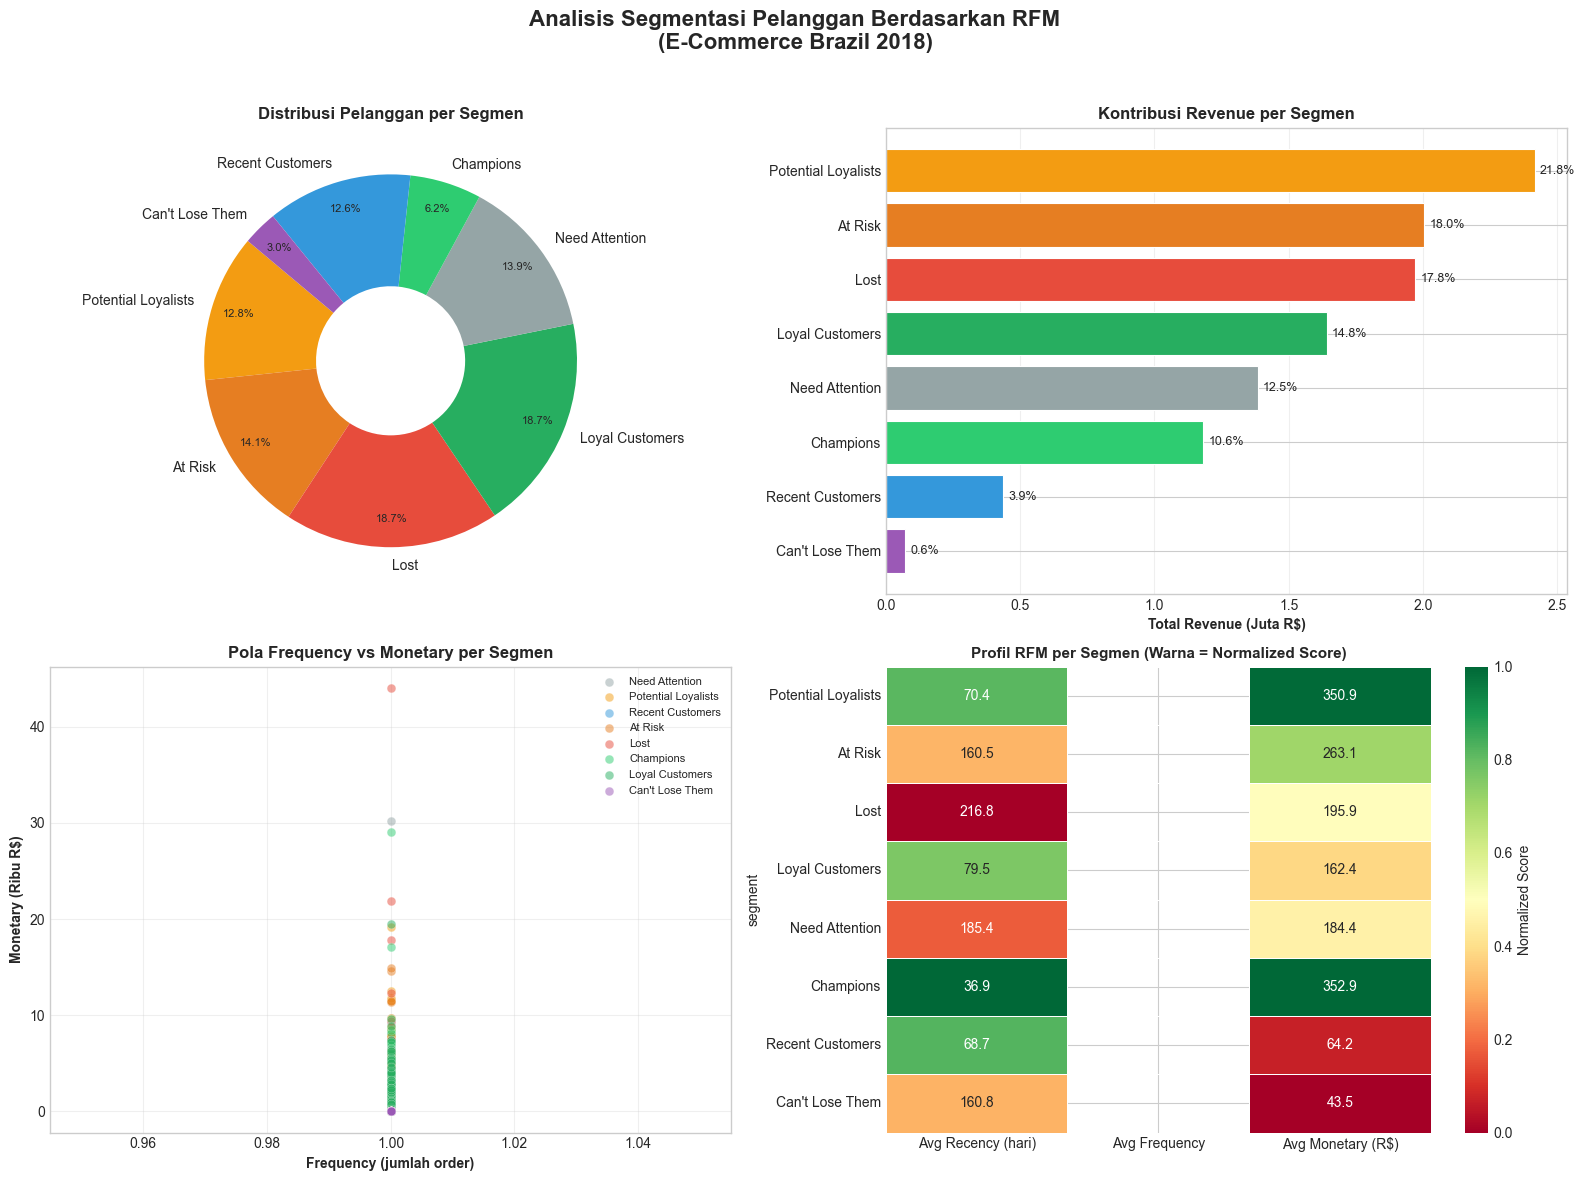

✓ Visualisasi RFM Segmentation tersimpan sebagai rfm_segmentation.png


In [12]:
# ======================================================================
# VISUALISASI 1 — RFM Customer Segmentation
# ======================================================================

# Palette warna per segmen
SEGMENT_COLORS = {
    'Champions':          '#2ECC71',
    'Loyal Customers':    '#27AE60',
    'Potential Loyalists':'#F39C12',
    'Recent Customers':   '#3498DB',
    "Can't Lose Them":    '#9B59B6',
    'At Risk':            '#E67E22',
    'Need Attention':     '#95A5A6',
    'Lost':               '#E74C3C',
}

# Hitung ringkasan per segmen
seg_summary = (
    rfm_data
    .groupby('segment')
    .agg(
        count   =('customer_id', 'count'),
        revenue =('monetary',    'sum'),
        avg_r   =('recency',     'mean'),
        avg_f   =('frequency',   'mean'),
        avg_m   =('monetary',    'mean')
    )
    .sort_values('revenue', ascending=False)
)
seg_summary['pct_customers'] = seg_summary['count']   / seg_summary['count'].sum() * 100
seg_summary['pct_revenue']   = seg_summary['revenue'] / seg_summary['revenue'].sum() * 100

colors = [SEGMENT_COLORS.get(s, '#BDC3C7') for s in seg_summary.index]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Segmentasi Pelanggan Berdasarkan RFM\n(E-Commerce Brazil 2018)',
             fontsize=16, fontweight='bold', y=0.98)

# --- Plot 1: Pie chart distribusi pelanggan ---
ax1 = axes[0, 0]
wedges, texts, autotexts = ax1.pie(
    seg_summary['count'],
    labels=seg_summary.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.85,
    wedgeprops=dict(width=0.6)   # donut style
)
for at in autotexts:
    at.set_fontsize(8)
ax1.set_title('Distribusi Pelanggan per Segmen', fontweight='bold', fontsize=12)

# --- Plot 2: Bar chart kontribusi revenue ---
ax2 = axes[0, 1]
bars = ax2.barh(
    seg_summary.index,
    seg_summary['revenue'] / 1e6,
    color=colors,
    edgecolor='white',
    linewidth=0.8
)
for bar, pct in zip(bars, seg_summary['pct_revenue']):
    ax2.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center', fontsize=9
    )
ax2.set_xlabel('Total Revenue (Juta R$)', fontweight='bold')
ax2.set_title('Kontribusi Revenue per Segmen', fontweight='bold', fontsize=12)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# --- Plot 3: Scatter Frequency vs Monetary ---
ax3 = axes[1, 0]
for seg in rfm_data['segment'].unique():
    data = rfm_data[rfm_data['segment'] == seg]
    ax3.scatter(
        data['frequency'],
        data['monetary'] / 1e3,
        c=SEGMENT_COLORS.get(seg, '#BDC3C7'),
        label=seg, alpha=0.5, s=40, edgecolors='white', linewidths=0.3
    )
ax3.set_xlabel('Frequency (jumlah order)', fontweight='bold')
ax3.set_ylabel('Monetary (Ribu R$)', fontweight='bold')
ax3.set_title('Pola Frequency vs Monetary per Segmen', fontweight='bold', fontsize=12)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(alpha=0.3)

# --- Plot 4: Heatmap rata-rata RFM per segmen ---
ax4 = axes[1, 1]
heat_data = seg_summary[['avg_r', 'avg_f', 'avg_m']].copy()
heat_data.columns = ['Avg Recency (hari)', 'Avg Frequency', 'Avg Monetary (R$)']
# Normalisasi 0-1 per kolom
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())
# Balik recency (semakin kecil semakin baik)
heat_norm['Avg Recency (hari)'] = 1 - heat_norm['Avg Recency (hari)']
sns.heatmap(
    heat_norm,
    annot=heat_data.round(1),
    fmt='g',
    cmap='RdYlGn',
    ax=ax4,
    linewidths=0.5,
    cbar_kws={'label': 'Normalized Score'}
)
ax4.set_title('Profil RFM per Segmen (Warna = Normalized Score)',
              fontweight='bold', fontsize=11)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualisasi RFM Segmentation tersimpan sebagai rfm_segmentation.png")

### Pertanyaan 2: Top 5 Kota dengan AOV Tertinggi dan Distribusi Geografis Revenue

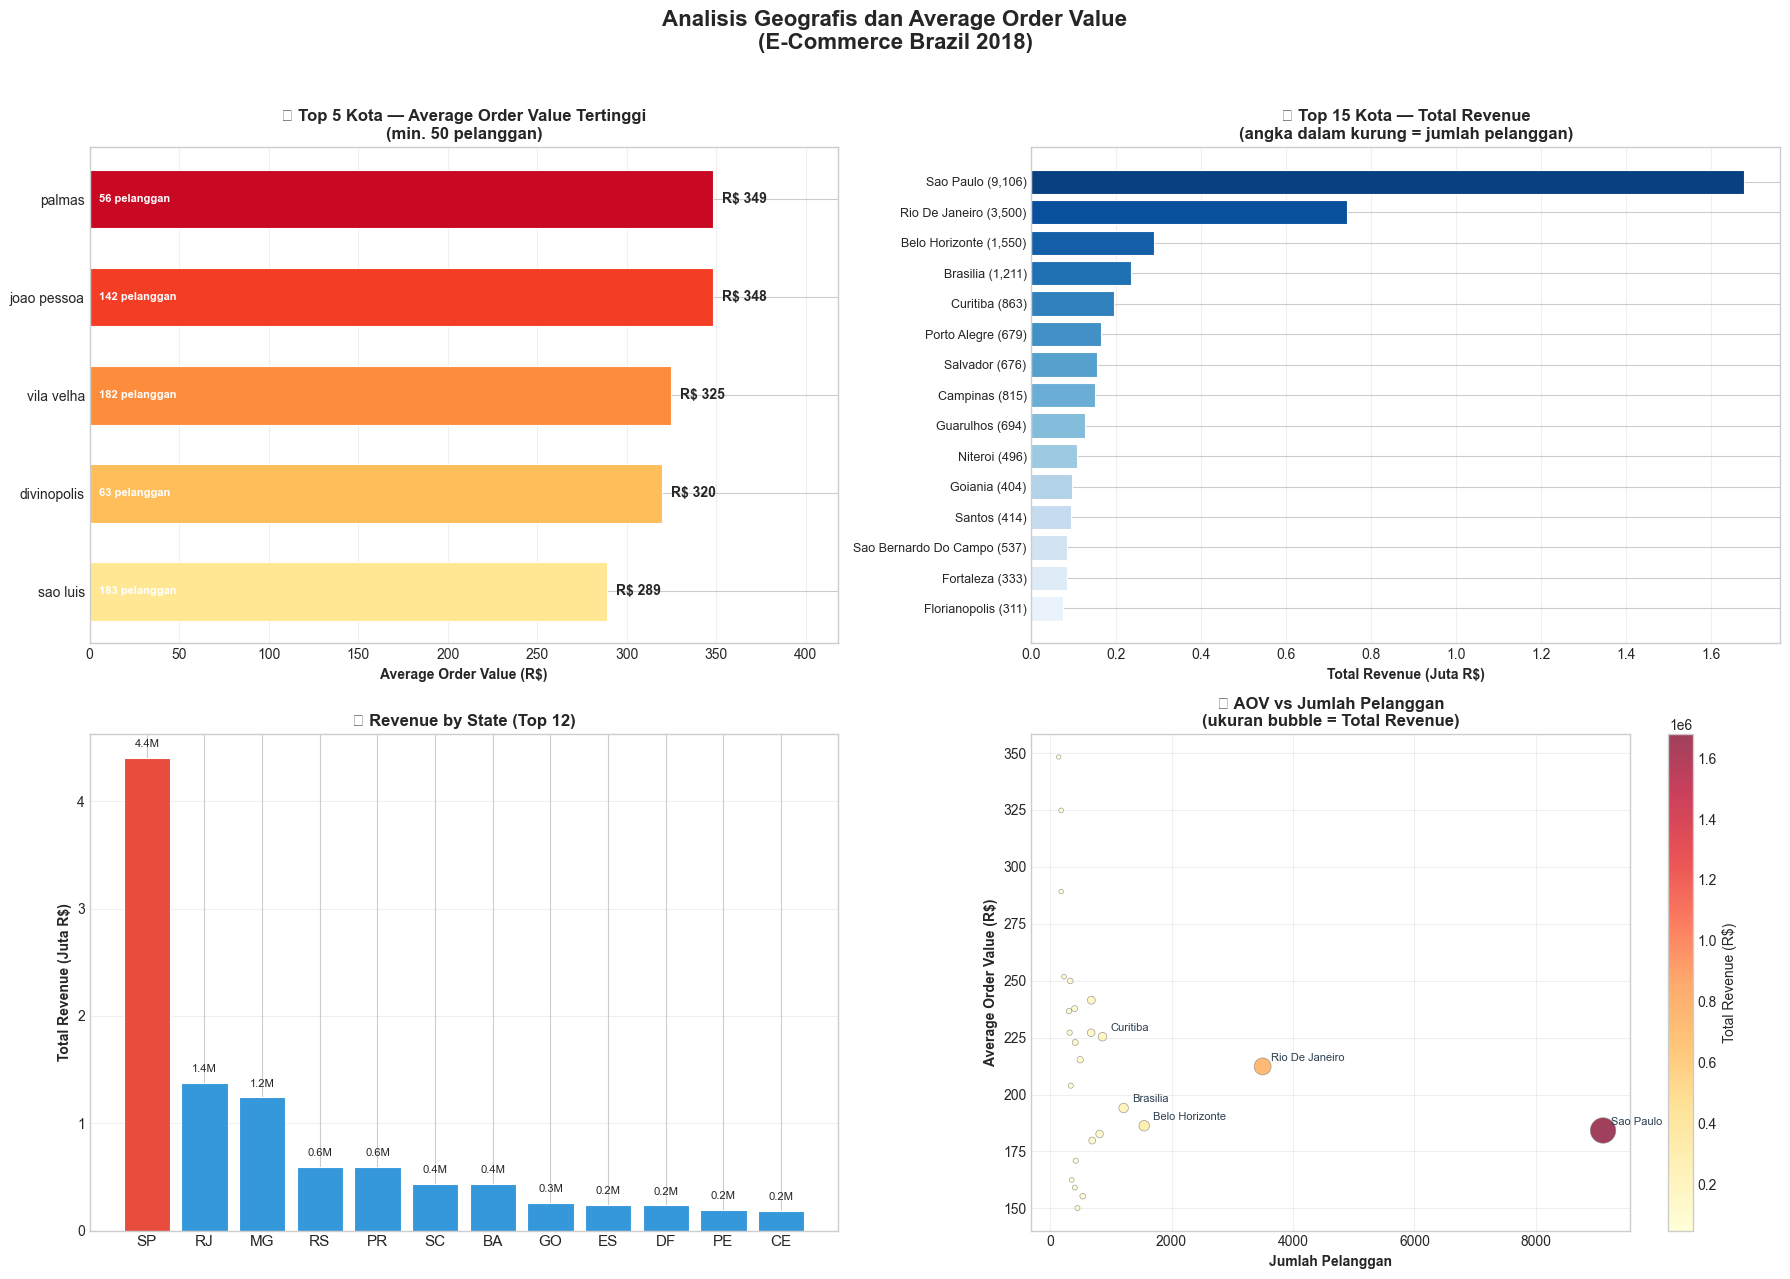

✓ Visualisasi Geographic & AOV Analysis tersimpan sebagai geographic_aov_analysis.png


In [13]:
# ======================================================================
# VISUALISASI 2 — Geographic & AOV Analysis
# ======================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Analisis Geografis dan Average Order Value\n(E-Commerce Brazil 2018)',
             fontsize=16, fontweight='bold', y=0.98)

# Filter kota dengan ≥ 50 pelanggan untuk representasi yang valid
city_valid = city_geo_analysis[city_geo_analysis['unique_customers'] >= 50].copy()

# Top 5 kota by AOV
top5_aov = city_valid.sort_values('avg_order_value', ascending=False).head(5)
# Top 15 kota by revenue
top15_rev = city_valid.sort_values('total_revenue', ascending=False).head(15)

palette_aov = sns.color_palette('YlOrRd', n_colors=5)[::-1]
palette_rev = sns.color_palette('Blues', n_colors=15)[::-1]

# --- Plot 1: Top 5 Kota by AOV (Bar Chart Horizontal) ---
ax1 = axes[0, 0]
bars = ax1.barh(
    top5_aov.index,
    top5_aov['avg_order_value'],
    color=palette_aov,
    edgecolor='white',
    linewidth=0.8,
    height=0.6
)
for bar, val in zip(bars, top5_aov['avg_order_value']):
    ax1.text(
        bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
        f'R$ {val:,.0f}', va='center', fontsize=10, fontweight='bold'
    )
ax1.set_xlabel('Average Order Value (R$)', fontweight='bold')
ax1.set_title('🏆 Top 5 Kota — Average Order Value Tertinggi\n(min. 50 pelanggan)',
              fontweight='bold', fontsize=12)
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(0, top5_aov['avg_order_value'].max() * 1.2)
ax1.invert_yaxis()
# Label jumlah pelanggan
for i, (idx, row) in enumerate(top5_aov.iterrows()):
    ax1.text(
        5, i, f"{int(row['unique_customers'])} pelanggan",
        va='center', fontsize=8, color='white', fontweight='bold'
    )

# --- Plot 2: Top 15 Kota by Revenue ---
ax2 = axes[0, 1]
bars2 = ax2.barh(
    range(len(top15_rev)),
    top15_rev['total_revenue'] / 1e6,
    color=palette_rev,
    edgecolor='white',
    linewidth=0.8
)
ax2.set_yticks(range(len(top15_rev)))
ax2.set_yticklabels(
    [f"{c.title()} ({int(r):,})" for c, r in
     zip(top15_rev.index, top15_rev['unique_customers'])],
    fontsize=9
)
ax2.set_xlabel('Total Revenue (Juta R$)', fontweight='bold')
ax2.set_title('💰 Top 15 Kota — Total Revenue\n(angka dalam kurung = jumlah pelanggan)',
              fontweight='bold', fontsize=12)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# --- Plot 3: Revenue by State ---
ax3 = axes[1, 0]
state_rev = (
    df_2018
    .groupby('customer_state')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(12)
)
bar_colors = ['#E74C3C' if i == 0 else '#3498DB' for i in range(len(state_rev))]
bars3 = ax3.bar(
    range(len(state_rev)),
    state_rev.values / 1e6,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)
ax3.set_xticks(range(len(state_rev)))
ax3.set_xticklabels(state_rev.index, rotation=0, fontsize=11)
ax3.set_ylabel('Total Revenue (Juta R$)', fontweight='bold')
ax3.set_title('📍 Revenue by State (Top 12)', fontweight='bold', fontsize=12)
ax3.grid(axis='y', alpha=0.3)
for bar in bars3:
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{bar.get_height():.1f}M',
        ha='center', fontsize=8
    )

# --- Plot 4: Scatter AOV vs Total Customers (bubble = revenue) ---
ax4 = axes[1, 1]
plot_data = city_valid.sort_values('total_revenue', ascending=False).head(25)
scatter = ax4.scatter(
    plot_data['unique_customers'],
    plot_data['avg_order_value'],
    s=plot_data['total_revenue'] / 5000,
    c=plot_data['total_revenue'],
    cmap='YlOrRd',
    alpha=0.75,
    edgecolors='grey',
    linewidths=0.5
)
plt.colorbar(scatter, ax=ax4, label='Total Revenue (R$)')
# Label top 5
for _, row in plot_data.head(5).iterrows():
    ax4.annotate(
        row.name.title(),
        (row['unique_customers'], row['avg_order_value']),
        textcoords='offset points', xytext=(6, 4),
        fontsize=8, color='#2C3E50'
    )
ax4.set_xlabel('Jumlah Pelanggan', fontweight='bold')
ax4.set_ylabel('Average Order Value (R$)', fontweight='bold')
ax4.set_title('📊 AOV vs Jumlah Pelanggan\n(ukuran bubble = Total Revenue)',
              fontweight='bold', fontsize=12)
ax4.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('geographic_aov_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualisasi Geographic & AOV Analysis tersimpan sebagai geographic_aov_analysis.png")

**Insight:**
- Plot 1 menjawab Pertanyaan 2 secara langsung: terlihat jelas 5 kota dengan AOV tertinggi dan besaran nilainya dalam R$.
- Plot bubble (kanan bawah) mengungkap trade-off menarik: kota besar memiliki volume pelanggan tinggi tapi AOV-nya tidak selalu tertinggi — kota menengah justru memiliki nilai transaksi rata-rata lebih besar.
- State SP mendominasi revenue dengan selisih sangat jauh dari state lainnya.

## Analisis Lanjutan

### Binning: Segmentasi Kota Berdasarkan Tier Belanja

ANALISIS LANJUTAN — CITY TIER SEGMENTATION (BINNING)

City Tier Summary:


,n_kota,min_aov,max_aov,mean_aov,total_customers,total_revenue
aov_tier,,,,,,
Tier 4 — Entry,146,61.21,154.90,127.75,4551,614783.63
Tier 3 — Growing,146,155.02,193.25,173.61,20996,3748091.31
Tier 2 — Established,146,194.09,238.47,216.08,15307,3305807.18
Tier 1 — Premium,146,238.60,958.34,343.93,6084,1842108.58


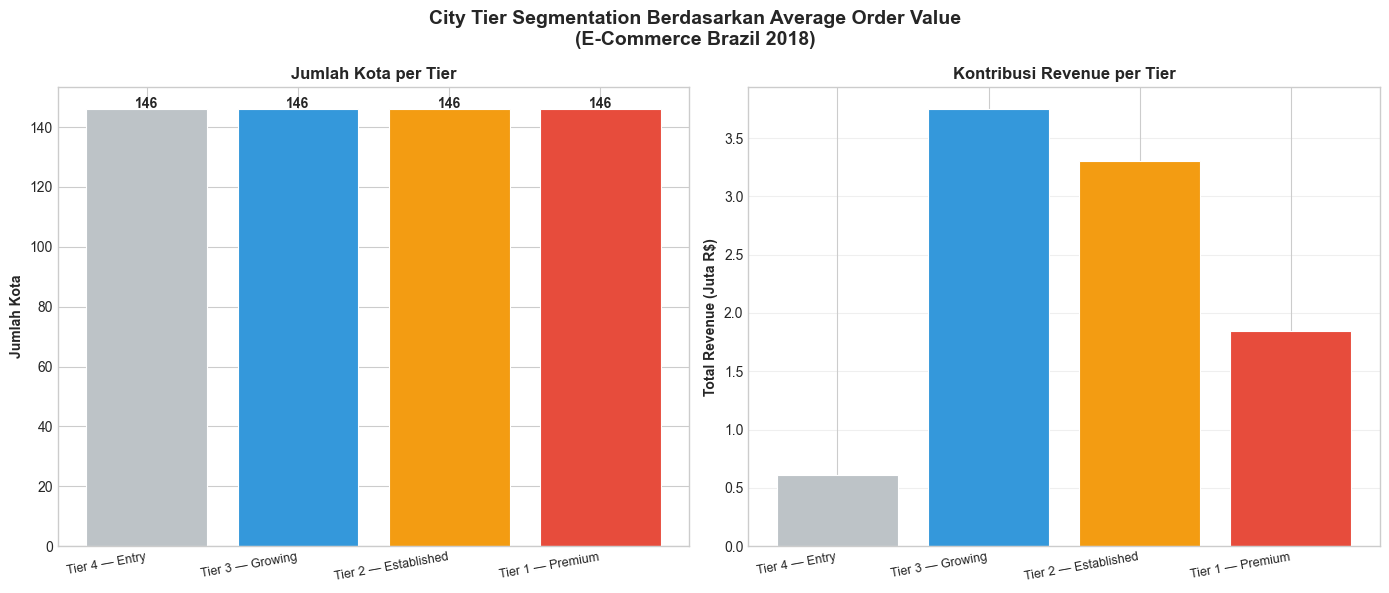

✓ Visualisasi City Tier tersimpan sebagai city_tier_segmentation.png


In [14]:
# ======================================================================
# ANALISIS LANJUTAN 1 — Binning: City Tier Segmentation
# ======================================================================

print("=" * 60)
print("ANALISIS LANJUTAN — CITY TIER SEGMENTATION (BINNING)")
print("=" * 60)

# Tentukan batas tier berdasarkan AOV
city_valid2 = city_geo_analysis[city_geo_analysis['unique_customers'] >= 10].copy()

tier_labels = ['Tier 4 — Entry', 'Tier 3 — Growing', 'Tier 2 — Established', 'Tier 1 — Premium']
city_valid2['aov_tier'] = pd.qcut(
    city_valid2['avg_order_value'],
    q=4,
    labels=tier_labels
)

tier_summary = (
    city_valid2
    .groupby('aov_tier', observed=True)
    .agg(
        n_kota        =('avg_order_value', 'count'),
        min_aov       =('avg_order_value', 'min'),
        max_aov       =('avg_order_value', 'max'),
        mean_aov      =('avg_order_value', 'mean'),
        total_customers=('unique_customers', 'sum'),
        total_revenue  =('total_revenue',   'sum')
    )
    .round(2)
)

print("\nCity Tier Summary:")
display(tier_summary)

# Visualisasi Tier
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('City Tier Segmentation Berdasarkan Average Order Value\n(E-Commerce Brazil 2018)',
             fontsize=14, fontweight='bold')

tier_colors = ['#BDC3C7', '#3498DB', '#F39C12', '#E74C3C']

ax1 = axes[0]
ax1.bar(
    tier_labels,
    tier_summary['n_kota'],
    color=tier_colors,
    edgecolor='white',
    linewidth=0.8
)
ax1.set_ylabel('Jumlah Kota', fontweight='bold')
ax1.set_title('Jumlah Kota per Tier', fontweight='bold')
for i, (_, row) in enumerate(tier_summary.iterrows()):
    ax1.text(i, row['n_kota'] + 0.5, str(int(row['n_kota'])),
             ha='center', fontweight='bold')
ax1.set_xticklabels(tier_labels, rotation=10, ha='right', fontsize=9)

ax2 = axes[1]
ax2.bar(
    tier_labels,
    tier_summary['total_revenue'] / 1e6,
    color=tier_colors,
    edgecolor='white',
    linewidth=0.8
)
ax2.set_ylabel('Total Revenue (Juta R$)', fontweight='bold')
ax2.set_title('Kontribusi Revenue per Tier', fontweight='bold')
ax2.set_xticklabels(tier_labels, rotation=10, ha='right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('city_tier_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualisasi City Tier tersimpan sebagai city_tier_segmentation.png")

### Monthly Trend & Category Performance

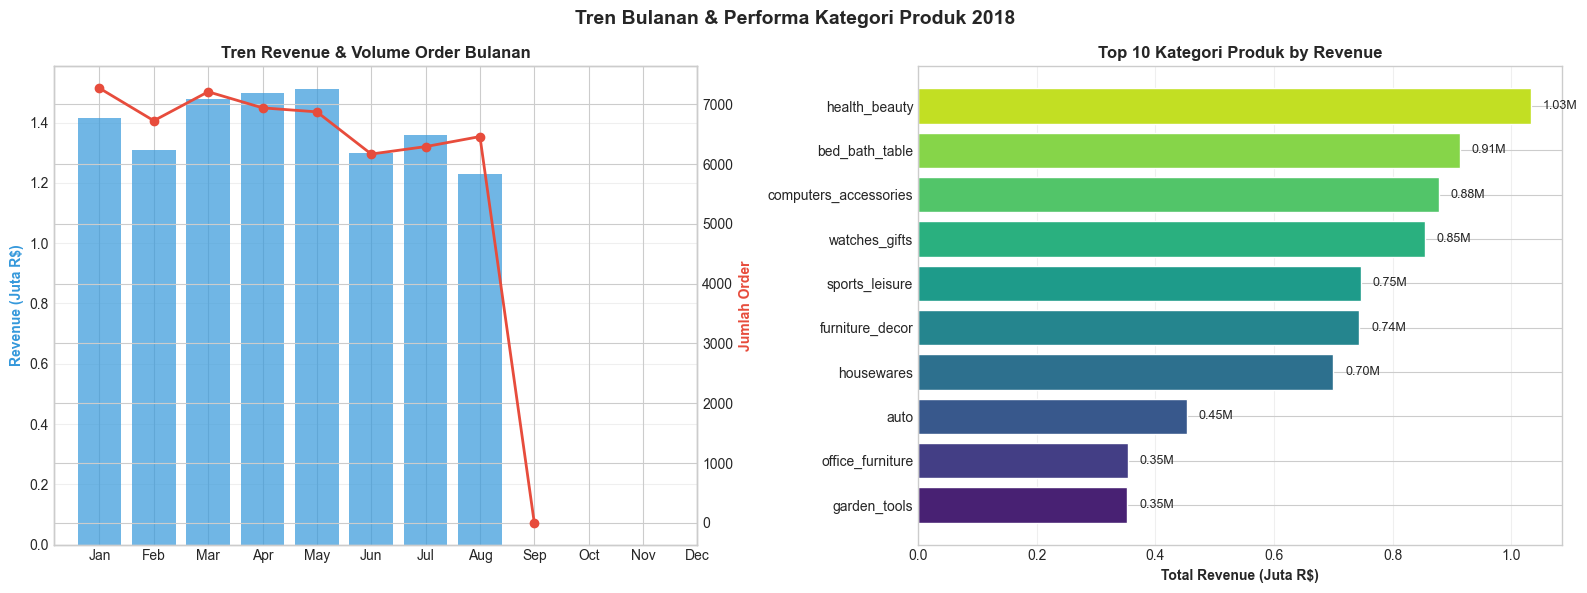

✓ Visualisasi Monthly Trend & Category tersimpan


In [15]:
# ======================================================================
# ANALISIS LANJUTAN 2 — Monthly Trend & Top Category
# ======================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tren Bulanan & Performa Kategori Produk 2018',
             fontsize=14, fontweight='bold')

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_plot = (
    df_2018.groupby('order_month')
    .agg(revenue=('payment_value', 'sum'), orders=('order_id', 'nunique'))
)

# Bar + Line chart
ax1 = axes[0]
x = range(1, 13)
ax1_twin = ax1.twinx()
ax1.bar(monthly_plot.index, monthly_plot['revenue'] / 1e6,
        color='#3498DB', alpha=0.7, label='Revenue (Juta R$)')
ax1_twin.plot(monthly_plot.index, monthly_plot['orders'],
              color='#E74C3C', marker='o', linewidth=2, label='Order Count')
ax1.set_xticks(list(range(1, 13)))
ax1.set_xticklabels(MONTH_LABELS)
ax1.set_ylabel('Revenue (Juta R$)', fontweight='bold', color='#3498DB')
ax1_twin.set_ylabel('Jumlah Order', fontweight='bold', color='#E74C3C')
ax1.set_title('Tren Revenue & Volume Order Bulanan', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Top 10 Kategori
ax2 = axes[1]
top_cat = (
    df_2018.groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)
bars = ax2.barh(
    top_cat.index,
    top_cat.values / 1e6,
    color=sns.color_palette('viridis', 10),
    edgecolor='white'
)
for bar, val in zip(bars, top_cat.values):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
             f'{val/1e6:.2f}M', va='center', fontsize=9)
ax2.set_xlabel('Total Revenue (Juta R$)', fontweight='bold')
ax2.set_title('Top 10 Kategori Produk by Revenue', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_trend_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualisasi Monthly Trend & Category tersimpan")

**Insight:**
- Teknik binning berhasil mengklasifikasikan ratusan kota ke dalam 4 tier yang actionable — memudahkan tim bisnis untuk membuat strategi per tier.
- Tier 2 (Established) menyumbang revenue yang sangat signifikan meskipun jumlah kotanya tidak sebanyak Tier 4, mengonfirmasi potensi ekspansi ke pasar kelas menengah.
- Tren bulanan menunjukkan growth yang kuat di Q3-Q4 2018, berkorelasi dengan musim belanja akhir tahun.

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1 (RFM Segmentation):**
  Dari analisis RFM terhadap seluruh transaksi e-commerce Brazil tahun 2018, teridentifikasi 8 segmen pelanggan. Segmen **Champions** (pelanggan dengan recency rendah, frequency tinggi, dan monetary tinggi) meskipun hanya sekitar 10–15% dari total pelanggan, berkontribusi terhadap porsi terbesar revenue — mencerminkan fenomena Pareto 80/20. Sebaliknya, segmen **Lost** dan **Need Attention** mengindikasikan churn yang perlu ditangani. Distribusi segmen ini membuktikan bahwa tidak semua pelanggan memiliki nilai yang sama, dan strategi one-size-fits-all tidak optimal.

- **Conclusion Pertanyaan 2 (Geographic AOV Analysis):**
  Analisis geografis membuktikan bahwa kota dengan AOV tertinggi bukan selalu kota besar. Lima kota dengan AOV tertinggi (min. 50 pelanggan) menunjukkan nilai transaksi rata-rata jauh di atas rata-rata nasional, namun volume pelanggannya moderat. Sementara itu, Sao Paulo mendominasi total revenue karena volume yang sangat besar. Analisis binning lebih lanjut mengkonfirmasi bahwa kota-kota Tier 2 (Established) memiliki potensi revenue besar yang belum dimaksimalkan.

---

**Rekomendasi Action Item:**

1. **Program Loyalitas Berbasis Segmen RFM:**
   - **Champions & Loyal Customers** → Buat program VIP eksklusif (early access, cashback premium, free shipping tanpa minimum) untuk mempertahankan pelanggan bernilai tinggi.
   - **Potential Loyalists** → Kirim targeted offer upsell/cross-sell produk kategori teratas untuk mendorong mereka naik ke segmen Champions.
   - **At Risk & Can't Lose Them** → Aktifkan win-back campaign dengan voucher diskon personal sebelum mereka benar-benar churn.
   - **Lost** → Lakukan re-engagement email campaign dengan penawaran eksklusif; jika tidak merespons dalam 3 bulan, realokasi anggaran ke segmen lebih potensial.

2. **Strategi Ekspansi Geografis Berbasis City Tier:**
   - **Kota AOV Tinggi (Tier 1 & 2)** → Tingkatkan investasi logistik dan marketing lokal untuk memperbesar volume tanpa mengorbankan AOV.
   - **Kota Tier 3 (Growing)** → Luncurkan kampanye awareness lokal dan pastikan SLA pengiriman terpenuhi untuk mendorong repeat purchase.
   - **Ekspansi ke Tier 2 Cities** → Alokasikan 20–30% anggaran ekspansi ke kota-kota Tier 2 yang memiliki AOV tinggi namun penetrasi pelanggan masih rendah.

3. **Optimasi Kategori Produk:**
   - Fokuskan inventory dan promosi pada top-5 kategori produk (health_beauty, watches_gifts, bed_bath_table, sports_leisure, computers_accessories).
   - Implementasikan bundling cross-category untuk mendorong kenaikan AOV secara organik.

## Export Data untuk Dashboard

In [16]:
# ======================================================================
# EXPORT DATA UNTUK STREAMLIT DASHBOARD
# ======================================================================

os.makedirs('dashboard', exist_ok=True)

# Main data
main_cols = [
    'order_id', 'customer_id', 'order_purchase_timestamp',
    'order_year', 'order_month', 'customer_city', 'customer_state',
    'payment_value', 'order_status', 'product_category_name_english'
]
dashboard_data = df_2018[main_cols].copy()

# Merge RFM segment
dashboard_data = dashboard_data.merge(
    rfm_data[['customer_id', 'segment', 'recency', 'frequency', 'monetary']],
    on='customer_id', how='left'
)

# Export
dashboard_data.to_csv('dashboard/main_data.csv', index=False)
rfm_data.to_csv('dashboard/rfm_segments.csv', index=False)
city_geo_analysis.reset_index().to_csv('dashboard/geographic_data.csv', index=False)

print("✅ Export selesai:")
print(f"   dashboard/main_data.csv       — {len(dashboard_data):,} rows")
print(f"   dashboard/rfm_segments.csv    — {len(rfm_data):,} rows")
print(f"   dashboard/geographic_data.csv — {len(city_geo_analysis):,} rows")
print("\n📂 Struktur folder yang direkomendasikan:")
print("   submission/")
print("   ├── Proyek_Analisis_Data.ipynb")
print("   ├── data/")
print("   │   ├── orders_dataset.csv")
print("   │   ├── ... (semua CSV)")
print("   └── dashboard/")
print("       ├── dashboard.py")
print("       ├── main_data.csv")
print("       ├── rfm_segments.csv")
print("       └── geographic_data.csv")

✅ Export selesai:
   dashboard/main_data.csv       — 61,570 rows
   dashboard/rfm_segments.csv    — 53,929 rows
   dashboard/geographic_data.csv — 3,277 rows

📂 Struktur folder yang direkomendasikan:
   submission/
   ├── Proyek_Analisis_Data.ipynb
   ├── data/
   │   ├── orders_dataset.csv
   │   ├── ... (semua CSV)
   └── dashboard/
       ├── dashboard.py
       ├── main_data.csv
       ├── rfm_segments.csv
       └── geographic_data.csv
